In [22]:
import pandas as pd
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv("Liver_Cancer.csv")

In [5]:
df.shape

(5000, 14)

In [6]:
df.isnull().sum()

age                        0
gender                     0
bmi                        0
alcohol_consumption        0
smoking_status             0
hepatitis_b                0
hepatitis_c                0
liver_function_score       0
alpha_fetoprotein_level    0
cirrhosis_history          0
family_history_cancer      0
physical_activity_level    0
diabetes                   0
liver_cancer               0
dtype: int64

In [7]:
df.physical_activity_level.value_counts()

physical_activity_level
Moderate    2027
Low         1957
High        1016
Name: count, dtype: int64

In [8]:
df.smoking_status.value_counts()

smoking_status
Never      2407
Former     1568
Current    1025
Name: count, dtype: int64

In [9]:
df.alcohol_consumption.value_counts()

alcohol_consumption
Never         2014
Occasional    1967
Regular       1019
Name: count, dtype: int64

In [10]:
df.describe()

,age,bmi,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,diabetes,liver_cancer
count,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,57.222800,25.90464,0.15120,0.095800,65.203900,15.109424,0.301600,0.241400,0.199200,0.217800
std,15.799224,5.10520,0.35828,0.294346,14.875477,15.196809,0.458998,0.427975,0.399439,0.412792
min,30.000000,8.10000,0.00000,0.000000,5.500000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,44.000000,22.50000,0.00000,0.000000,54.800000,4.357500,0.000000,0.000000,0.000000,0.000000
50%,57.000000,25.90000,0.00000,0.000000,65.200000,10.340000,0.000000,0.000000,0.000000,0.000000
75%,71.000000,29.30000,0.00000,0.000000,75.200000,21.010000,1.000000,0.000000,0.000000,0.000000
max,84.000000,43.70000,1.00000,1.000000,115.700000,136.800000,1.000000,1.000000,1.000000,1.000000


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.sample(5)

,age,gender,bmi,alcohol_consumption,smoking_status,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,physical_activity_level,diabetes,liver_cancer
761,42,Female,27.4,Never,Never,1,0,41.5,15.83,0,1,Low,0,0
3225,48,Male,19.0,Occasional,Never,0,0,100.6,28.68,1,0,Low,0,0
787,50,Female,26.1,Never,Current,1,0,69.8,10.04,0,0,Low,0,0
671,54,Male,21.7,Never,Never,0,0,77.8,1.90,0,0,Moderate,0,0
4657,42,Male,28.9,Occasional,Current,0,1,72.9,0.89,1,0,Moderate,0,0


In [13]:
x_train,x_test,y_train,y_test = train_test_split(df.drop('liver_cancer', axis=1),df['liver_cancer'],test_size=0.3, random_state=0)

In [14]:
x_train.sample(5)

,age,gender,bmi,alcohol_consumption,smoking_status,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,physical_activity_level,diabetes
3745,38,Male,26.3,Occasional,Never,0,0,78.1,15.45,1,0,Low,0
1189,49,Male,20.4,Never,Former,0,0,58.6,1.22,0,0,Moderate,0
4305,51,Male,28.4,Never,Current,0,0,63.6,1.43,1,0,Low,0
1090,76,Male,27.3,Occasional,Never,1,1,81.1,14.04,0,0,High,0
466,52,Female,20.6,Occasional,Current,0,0,52.3,1.19,0,0,Low,0


In [15]:
# oe = 
# oe.fit_transform(x_train[])
trans = ColumnTransformer(transformers = 
                          [('oe',OrdinalEncoder(categories=[['Low','Moderate','High']]),['physical_activity_level']),
                           ('ohe',OneHotEncoder(drop='first',sparse_output=False),['gender','alcohol_consumption','smoking_status'])
                          ],
                          remainder='passthrough'
                         )

In [16]:
x_train_trans = pd.DataFrame(trans.fit_transform(x_train))

In [17]:
x_train_trans

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.0,0.0,1.0,0.0,1.0,0.0,81.0,19.6,1.0,0.0,59.5,26.66,1.0,0.0,0.0
1,2.0,1.0,0.0,0.0,0.0,1.0,81.0,27.3,0.0,0.0,57.6,11.62,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,1.0,59.0,26.7,0.0,1.0,74.4,9.10,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,1.0,49.0,29.7,0.0,0.0,67.1,7.03,1.0,0.0,0.0
4,2.0,1.0,0.0,0.0,0.0,1.0,55.0,34.9,0.0,0.0,81.9,14.04,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,2.0,0.0,0.0,0.0,1.0,0.0,36.0,29.3,0.0,0.0,73.7,2.57,0.0,0.0,1.0
3496,1.0,1.0,0.0,1.0,0.0,0.0,65.0,22.0,0.0,0.0,69.4,15.00,0.0,0.0,0.0
3497,1.0,1.0,0.0,0.0,0.0,1.0,51.0,20.8,0.0,0.0,74.4,30.61,0.0,0.0,0.0
3498,2.0,0.0,0.0,1.0,0.0,1.0,33.0,21.6,0.0,0.0,61.3,16.51,0.0,1.0,0.0


In [18]:
x_test_trans = pd.DataFrame(trans.transform(x_test))

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('preprocess', trans),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipe.fit(x_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('oe', ...), ('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [20]:
from sklearn.metrics import accuracy_score
y_pred = pipe.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9266666666666666


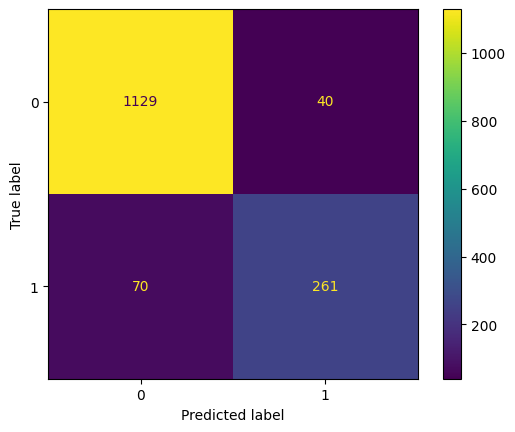

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.97      0.95      1169
           1       0.87      0.79      0.83       331

    accuracy                           0.93      1500
   macro avg       0.90      0.88      0.89      1500
weighted avg       0.93      0.93      0.93      1500



In [25]:
from sklearn.metrics import roc_auc_score

y_prob = pipe.predict_proba(x_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)


ROC-AUC: 0.9687056616159136


In [26]:
y_prob = pipe.predict_proba(x_test)[:, 1]

# lower threshold to reduce false negatives
y_pred_03 = (y_prob >= 0.3).astype(int)

from sklearn.metrics import confusion_matrix, classification_report


print(classification_report(y_test, y_pred_03))
print(confusion_matrix(y_test, y_pred_03))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94      1169
           1       0.76      0.86      0.80       331

    accuracy                           0.91      1500
   macro avg       0.86      0.89      0.87      1500
weighted avg       0.91      0.91      0.91      1500

[[1078   91]
 [  47  284]]


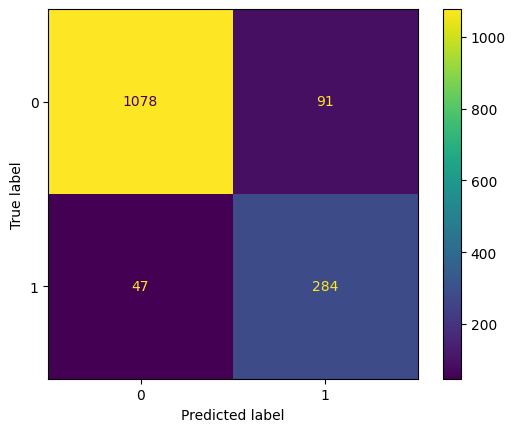

In [27]:
cm = confusion_matrix(y_test, y_pred_03)
ConfusionMatrixDisplay(cm).plot()


In [28]:
from joblib import dump, load

dump(pipe, "liver_cancer_model.joblib")
model = load("liver_cancer_model.joblib")
